In [1]:
# Imports
import matplotlib.pyplot as plt
from astropy import units as u
from astropy.io import fits
from astropy.wcs import WCS
from astropy.visualization.wcsaxes import WCSAxes
from astropy.coordinates import SkyCoord, FK5
from spectral_cube import SpectralCube
from velocity_tools import extract_streamline, gradient_descent, stream_lines_grad
from velocity_tools import stream_lines # won't use this directly, but needed to compare with stream_lines_grad
import os

import warnings
warnings.filterwarnings('ignore', message='.*PV2_1.*')
warnings.filterwarnings('ignore', message='.*PV2_2.*')
warnings.filterwarnings('ignore', message='.*TIMESYS.*')

# Settings
hltau_c= SkyCoord("4h31m38.43s", "+18d13m57.19s", frame='fk5')
hltau_ref = hltau_c.skyoffset_frame()
distance = 147 #parsecs
cubefile = 'test_data/HLTAU_HCOp32.fits'
file_TdV = 'test_data/HLTAU_HCOp32_TdV.fits'


/Users/laurenmason/.pyenv/versions/.vtenv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### TODO: Extract streamer cube from original cube
### Prepare the 1D streamer emission from the cube

In [2]:
# get the spectralcube object from the data using spectral-cube
hdu = fits.open(cubefile)[0]
cube = SpectralCube.read(hdu).with_spectral_unit(u.km/u.s, rest_value=hdu.header['RESTFRQ']*u.Hz)

# if the mom0 map isn't made yet, make it
if not os.path.exists(file_TdV):
    cube_mom0 = cube.moment0()
    hdu_mom0 = cube_mom0.hdu
    hdu_mom0.writeto(file_TdV)
print("Loaded cube with shape:", cube.shape)

# TODO: this streamer extraction should be replaced with clustering-based streamer extraction

# extract the subcube with the streamer (we got this from the tipsy tutorial, no need to plot)
## Limits for extracting subcube with streamer
vmin = 7    # Min. vel. of streamer
vmax = 10
xmin = -3   # Min R.A. offset to consider for streamer
xmax = -1
ymin = -3   # Min. Decl. offset to consider for stremar
ymax = 0.5
rms_thresh = 4  # sigma threshold for streamer

# extract the streamer subcube
info_header = cube.header  # header of the cube, contains required information
x_conv_fac = 1/60/60/info_header['CDELT1']
xmin_p = int((xmin*x_conv_fac)+info_header['CRPIX1'])
xmax_p = int((xmax*x_conv_fac)+info_header['CRPIX1'])
y_conv_fac = 1/60/60/info_header['CDELT2']
ymin_p = int((ymin*y_conv_fac)+info_header['CRPIX2'])
ymax_p = int((ymax*y_conv_fac)+info_header['CRPIX2'])
vunit = cube.spectral_axis.unit
## Note: a check can be added to see if requested limits are within the limits of the cube itself

streamer_cubev = cube.spectral_slab(vmin*vunit,vmax*vunit)    # Selecting velocities
streamer_cubevc = streamer_cubev[:,min(ymin_p,ymax_p):max(ymin_p,ymax_p)   
                    ,min(xmin_p,xmax_p):max(xmin_p,xmax_p)]   # Selecting pixels
#     print(min(ymin_p,ymax_p),max(ymin_p,ymax_p),min(xmin_p,xmax_p),max(xmin_p,xmax_p)) 
streamer_cube = streamer_cubevc.with_mask(streamer_cubevc > rms_thresh*streamer_cubevc.mad_std())  # Removing low flux values 


Loaded cube with shape: (500, 401, 401)


In [3]:

# Extract 1D streamline from the data cube
pc_coords, pc_means, pc_stds = extract_streamline.reduce_to_1D(streamer_cube, n_elements=10)

Starting reduction
Created coordinate arrays
Got point cloud with 14974 points
Partition boundaries for projected distance metric: [1.031 1.122 1.176 1.234 1.3   1.383 1.48  1.602 1.732 1.898 3.251]


Text(0.5, 1.0, 'Extracted 1D Streamer emission')

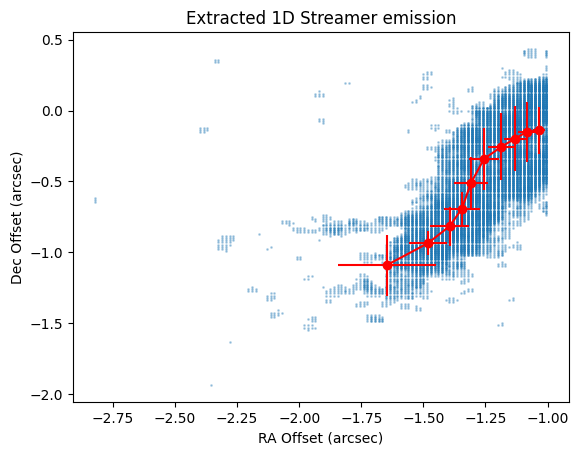

In [4]:
# plot it
import matplotlib.pyplot as plt
# plot the observed data points as a scatter
plt.scatter(pc_coords[0], pc_coords[1], s=1, alpha=0.3, label='Point cloud')
# plot the extracted 1D streamline with error bars
plt.errorbar(pc_means[0], pc_means[1], xerr=pc_stds[0], yerr=pc_stds[1], fmt='o-', label='Extracted 1D Streamline', color='red')
plt.xlabel('RA Offset (arcsec)')
plt.ylabel('Dec Offset (arcsec)')
plt.title('Extracted 1D Streamer emission')

### Initial guess at parameters, and plot

This plot shows that stream_lines_grad is not working well and has some kind of instability.

Running stream_lines...
rc=1.9220526946751497 AU
20.0 AU
tolerance  7.180697793600001e-07
Running stream_lines_grad...
Plotting results...


/var/folders/cf/gbp0295d3dgg0vcn3fvpmybw0000gr/T/ipykernel_34617/1231546999.py:63: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


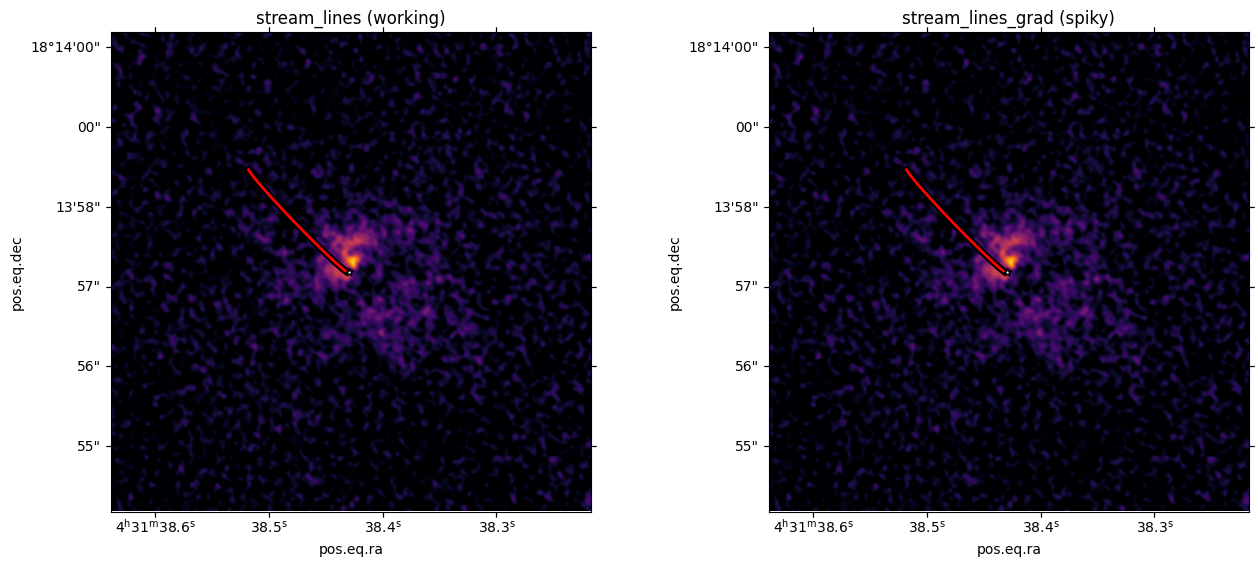

In [5]:
# Initial guesses at params
theta0 = 130.*u.deg
r0 = 1000*u.au
phi0 = 70.*u.deg
v_r0 = 0*u.km/u.s
omega0 = 4e-13/u.s
v_lsr = 7.14*u.km/u.s
inc = -43*u.deg
PA_ang = 130*u.deg
Mstar = 2.1*u.Msun

# Run the forward model with initial params - using stream_lines
# x = RA offset (au), y = velocity (km/s), z = Dec offset (au)
print("Running stream_lines...")
(x1, y1, z1), (vx1, vy1, vz1) = stream_lines.xyz_stream(
                mass=Mstar, r0=r0, theta0=theta0, phi0=phi0,
                omega=omega0, v_r0=v_r0, inc=inc, pa=PA_ang,
                rmin=0.5e2*u.au, deltar=20*u.au) #<- decrease deltar for more accurate streamer calculation
dra_stream1 = -x1.value / distance * u.arcsec 
ddec_stream1 = z1.value / distance * u.arcsec
fil1 = SkyCoord(dra_stream1, ddec_stream1, frame=hltau_ref).transform_to(FK5)

# Run the forward model with initial params - using stream_lines_grad
# x = RA offset (au), y = velocity (km/s), z = Dec offset (au)
print("Running stream_lines_grad...")
(x2, y2, z2), (vx2, vy2, vz2) = stream_lines_grad.xyz_stream(
                mass=Mstar, r0=r0, theta0=theta0, phi0=phi0,
                omega=omega0, v_r0=v_r0, inc=inc, pa=PA_ang,
                rmin=0.5e2*u.au, deltar=20*u.au) #<- decrease deltar for more accurate streamer calculation
dra_stream2 = -x2._value / distance * u.arcsec # note the _value to get raw number for stream_lines_grad
ddec_stream2 = z2._value / distance * u.arcsec
fil2 = SkyCoord(dra_stream2, ddec_stream2, frame=hltau_ref).transform_to(FK5)

print("Plotting results...")
# Load the moment 0 data
hdu = fits.open(file_TdV)[0]
wcs_TdV = WCS(hdu.header)

# Create figure with two subplots side by side
plt.close('all')
fig = plt.figure(figsize=(14, 6))

# Left subplot - stream_lines
ax1 = WCSAxes(fig, [0.05, 0.1, 0.4, 0.8], wcs=wcs_TdV.celestial)
fig.add_axes(ax1)
im1 = ax1.imshow(hdu.data, cmap='inferno', vmin=0, vmax=160.e-3)
ax1.scatter(hltau_c.ra, hltau_c.dec, marker='*', transform=ax1.get_transform('world'),
    facecolor='white', edgecolor='black')
ax1.plot(fil1.ra, fil1.dec, color='black', transform=ax1.get_transform('world'), linewidth=5)
ax1.plot(fil1.ra, fil1.dec, color='red', transform=ax1.get_transform('world'), linewidth=2)
ax1.set_title('stream_lines (working)')

# Right subplot - stream_lines_grad
ax2 = WCSAxes(fig, [0.52, 0.1, 0.4, 0.8], wcs=wcs_TdV.celestial)
fig.add_axes(ax2)
im2 = ax2.imshow(hdu.data, cmap='inferno', vmin=0, vmax=160.e-3)
ax2.scatter(hltau_c.ra, hltau_c.dec, marker='*', transform=ax2.get_transform('world'),
    facecolor='white', edgecolor='black')
ax2.plot(fil2.ra, fil2.dec, color='black', transform=ax2.get_transform('world'), linewidth=5)
ax2.plot(fil2.ra, fil2.dec, color='red', transform=ax2.get_transform('world'), linewidth=2)
ax2.set_title('stream_lines_grad (spiky)')

plt.tight_layout()
plt.show()